# 07 · Análisis exhaustivo: logística, precio y vendedores  *(sección 7 del script)*

**Qué hacemos:** profundizamos los puntos que quedaron abiertos en la sección exploratoria, con **8 respuestas concretas**:

1. ¿Qué categorías concentran las demoras?
2. ¿La distancia cliente-vendedor influye en la demora?
3. ¿El peso y el volumen del producto influyen en la entrega y en el flete?
4. ¿Cómo varía el ticket por estado/región?
5. ¿Cómo se relacionan entre sí las variables numéricas clave? (mapa de correlaciones)
6. ¿Qué vendedores concentran el negocio y cuáles rinden peor?
7. ¿Las compras de más valor se financian en más cuotas?
8. ¿Qué tan concentrada está la facturación? (Pareto)

**Para qué:** pasar de "describir" a "explicar": aislar los drivers logísticos y de precio con cortes por categoría, región y vendedor — el insumo directo de las hipótesis del notebook 10.

## Celda estándar: carga del artefacto + guardado de figuras

In [1]:
# Celda estándar (detallada en 01_configuracion_inicial.ipynb)
%matplotlib inline

import re
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

BASE = Path.cwd()
if not (BASE / "data").exists() and (BASE.parent / "data").exists():
    BASE = BASE.parent

CSV_UNIFICADO = BASE / "data" / "olist_dataset_unificado.csv"
PIPELINE_DIR = BASE / "data" / "pipeline"
FIGS_DIR = BASE / "figuras_eda"

OLIST_BLUE = "#0A4EE4"
OLIST_BLUE_DARK = "#0D366B"
OLIST_GRAY = "#52514E"
PALETA_CATEGORICA = ["#0A4EE4", "#eb6834", "#1baf7a", "#eda100",
                     "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SUDESTE = {"SP", "RJ", "MG", "ES"}

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": OLIST_GRAY,
    "text.color": "#0b0b0b",
    "xtick.color": OLIST_GRAY,
    "ytick.color": OLIST_GRAY,
    "font.family": "sans-serif",
})
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 50)

# --- Carga del artefacto del notebook 04 ---
COLUMNAS_FECHA = [
    "shipping_limit_date", "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

RUTA_FEATURES = PIPELINE_DIR / "02_df_features.csv"
if not RUTA_FEATURES.exists():
    raise FileNotFoundError(
        f"No existe {RUTA_FEATURES}. Ejecutá primero los notebooks 02, 03 y 04."
    )

df = pd.read_csv(RUTA_FEATURES)
for col in COLUMNAS_FECHA:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df["mes_compra"] = df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

# --- Guardado de figuras de este notebook ---
def configurar_guardado(prefijo):
    FIGS_DIR.mkdir(exist_ok=True)
    contador = {"n": 0}

    def guardar():
        contador["n"] += 1
        ruta = FIGS_DIR / f"{prefijo}_{contador['n']:02d}.png"
        plt.savefig(ruta, dpi=110, bbox_inches="tight")
        return ruta

    return guardar


guardar_fig = configurar_guardado("nb07")
print(f"filas={df.shape[0]:,} columnas={df.shape[1]} | figuras -> {FIGS_DIR}")

filas=112,650 columnas=43 | figuras -> D:\Ciencia de Datos\Proyecto Integrador\trabajo_ integrador_versionNati\trabajo_ integrador_versionNati\figuras_eda


## 1 — ¿Qué categorías tienen mayor demora?

**Qué hacemos:** por categoría de producto, calculamos cantidad de pedidos, tiempo de entrega promedio y **% de envíos demorados**; filtramos las categorías con **al menos 30 pedidos** (umbral `UMBRAL_MIN_PEDIDOS`) para no analizar categorías demasiado chicas cuyo % sea ruido, y graficamos las **10 peores**.

**Para qué:** responder concretamente **dónde revisar la logística primero**, en vez de tratar a todas las categorías por igual.

> El filtro con umbral mínimo es una **buena práctica**: en una categoría con 3 pedidos,1 demorado ya es 33% — no es información, es azar.

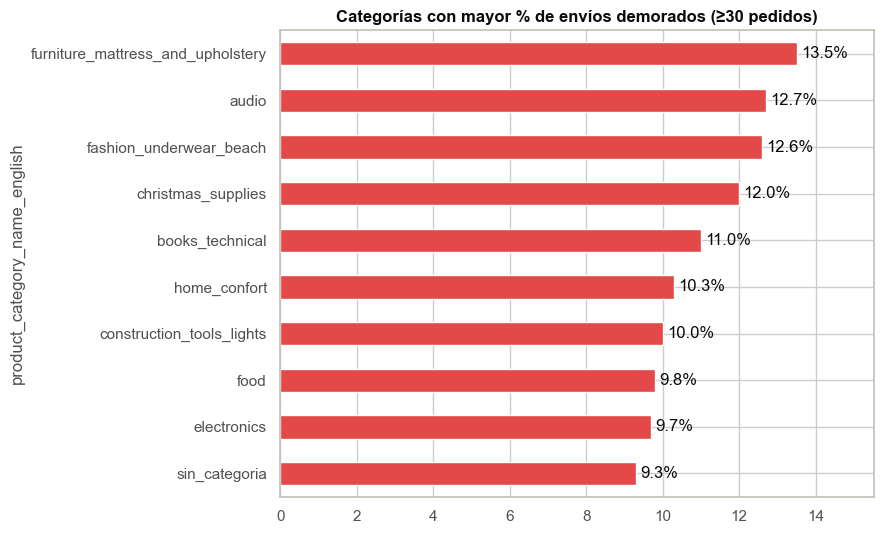

,pedidos,tiempo_entrega_promedio,pct_demorado
product_category_name_english,,,
furniture_mattress_and_upholstery,38,13.9,13.5
audio,350,12.9,12.7
fashion_underwear_beach,121,13.3,12.6
christmas_supplies,128,15.3,12.0
books_technical,260,10.2,11.0
home_confort,397,13.0,10.3
construction_tools_lights,244,9.2,10.0
food,450,9.1,9.8
electronics,2550,12.4,9.7


In [2]:
UMBRAL_MIN_PEDIDOS = 30

demora_categoria = df.groupby("product_category_name_english").agg(
    pedidos=("order_id", "nunique"),
    tiempo_entrega_promedio=("tiempo_entrega_dias", "mean"),
    pct_demorado=("envio_demorado", "mean"),
)
demora_categoria_filtrada = demora_categoria.query("pedidos >= @UMBRAL_MIN_PEDIDOS")
if demora_categoria_filtrada.empty:
    demora_categoria_filtrada = demora_categoria  # dataset chico: no filtramos por volumen

demora_categoria_filtrada = demora_categoria_filtrada.copy()
demora_categoria_filtrada["pct_demorado"] = (demora_categoria_filtrada["pct_demorado"] * 100).round(1)
demora_categoria_filtrada["tiempo_entrega_promedio"] = demora_categoria_filtrada["tiempo_entrega_promedio"].round(1)
peores_categorias = demora_categoria_filtrada.sort_values("pct_demorado", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5.5))
barras = peores_categorias["pct_demorado"].sort_values().plot(kind="barh", color=PALETA_CATEGORICA[7], ax=ax)
ax.set_xlim(0, peores_categorias["pct_demorado"].max() * 1.15)
ax.bar_label(barras.containers[0], fmt="%.1f%%", padding=3)
ax.set_title("Categorías con mayor % de envíos demorados (≥30 pedidos)")
plt.tight_layout()
guardar_fig()
plt.show()

peores_categorias

**Insight:** las categorías con **peor % de demora no son necesariamente las de mayor volumen** (notebook 06) — hay categorías chicas o medianas que logísticamente rinden peor, probablemente por productos más voluminosos/pesados o vendedores más alejados (se retoma en los dos bloques siguientes).

## 2 — ¿La distancia influye en la demora?

**Qué hacemos:** boxplot de `distancia_km` entre pedidos **a tiempo** y **demorados** (con la mediana de cada grupo anotada), y **correlación de Pearson** entre `distancia_km` y `tiempo_entrega_dias`.

**Para qué:** ir **más allá del proxy** Sudeste/resto del país (hipótesis 3) usando la **distancia real en kilómetros** calculada con Haversine en el notebook 04.

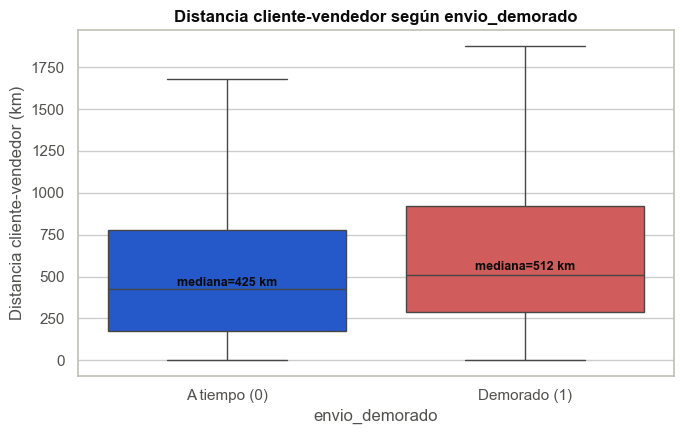

Correlación distancia_km vs. tiempo_entrega_dias: 0.39


In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
datos_dist = df.dropna(subset=["envio_demorado", "distancia_km"])
sns.boxplot(data=datos_dist, x="envio_demorado", y="distancia_km",
            palette=[OLIST_BLUE, PALETA_CATEGORICA[7]], ax=ax, showfliers=False)
medianas_dist = datos_dist.groupby("envio_demorado")["distancia_km"].median()
for i, val in enumerate(medianas_dist):
    ax.text(i, val + val * 0.05, f"mediana={val:.0f} km", ha="center", fontsize=9, fontweight="bold")
ax.set_xticklabels(["A tiempo (0)", "Demorado (1)"])
ax.set_ylabel("Distancia cliente-vendedor (km)")
ax.set_title("Distancia cliente-vendedor según envio_demorado")
plt.tight_layout()
guardar_fig()
plt.show()

corr_dist = df[["distancia_km", "tiempo_entrega_dias"]].corr().iloc[0, 1]
print(f"Correlación distancia_km vs. tiempo_entrega_dias: {corr_dist:.2f}")

**Insight:** los envíos demorados tienen una **distancia mediana mayor** que los que llegan a tiempo, y la correlación entre distancia y tiempo de entrega es **positiva y considerable** — la distancia real (no solo la región) es un **factor logístico concreto** detrás de las demoras. Se contrasta formalmente con Spearman en el notebook 10.

## 3 — ¿Peso y volumen influyen en la entrega y en el flete?

**Qué hacemos:** scatter (sobre una **muestra de 3.000 filas**, `random_state=42` para que sea reproducible) de (a) peso vs. tiempo de entrega y (b) volumen vs. `flete_ratio`; y matriz de correlación entre peso, volumen y las variables de logística/costo.

**Para qué:** responder si el **tamaño físico del paquete** mueve la aguja de la demora o solo del costo de envío. Se muestrea porque con ~112 mil puntos los scatters quedan saturados (y tardan) sin aportar más información.

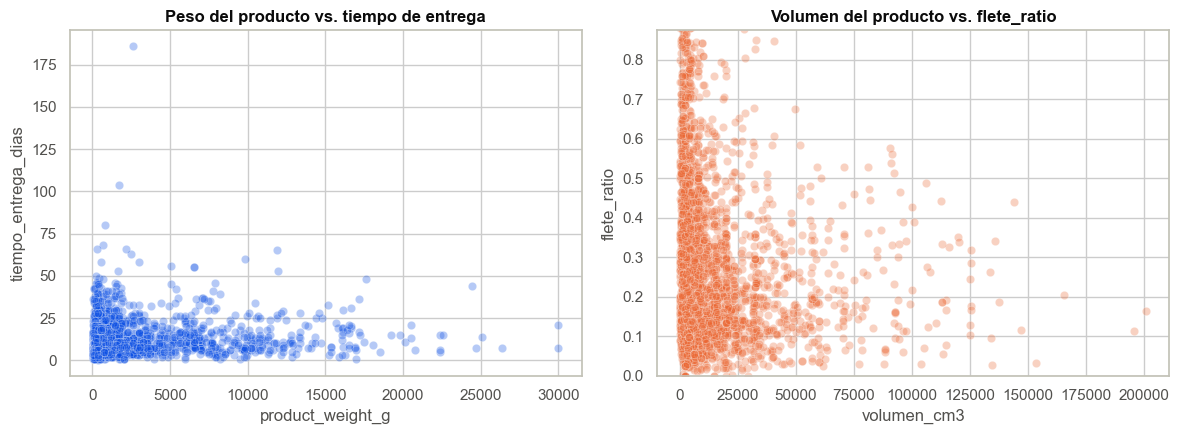

Correlaciones:
                     product_weight_g  volumen_cm3  tiempo_entrega_dias  \
product_weight_g                 1.00         0.80                 0.09   
volumen_cm3                      0.80         1.00                 0.08   
tiempo_entrega_dias              0.09         0.08                 1.00   
envio_demorado                   0.02         0.02                 0.59   
flete_ratio                     -0.10        -0.09                 0.07   

                     envio_demorado  flete_ratio  
product_weight_g               0.02        -0.10  
volumen_cm3                    0.02        -0.09  
tiempo_entrega_dias            0.59         0.07  
envio_demorado                 1.00         0.02  
flete_ratio                    0.02         1.00  


In [4]:
muestra_pv = df.sample(n=min(3000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=muestra_pv, x="product_weight_g", y="tiempo_entrega_dias",
                 alpha=0.3, color=OLIST_BLUE, ax=axes[0])
axes[0].set_title("Peso del producto vs. tiempo de entrega")

sns.scatterplot(data=muestra_pv, x="volumen_cm3", y="flete_ratio",
                 alpha=0.3, color=PALETA_CATEGORICA[1], ax=axes[1])
axes[1].set_ylim(0, df["flete_ratio"].quantile(0.95))
axes[1].set_title("Volumen del producto vs. flete_ratio")
plt.tight_layout()
guardar_fig()
plt.show()

print("Correlaciones:")
print(df[["product_weight_g", "volumen_cm3", "tiempo_entrega_dias", "envio_demorado", "flete_ratio"]]
      .corr().round(2))

**Insight:** peso y volumen tienen **correlación baja con el tiempo de entrega** y con la demora (el tamaño físico del paquete **no** es un driver fuerte de la demora), pero **correlación más alta con `flete_ratio`**: productos más pesados/grandes pagan proporcionalmente más flete — tiene sentido de negocio y **valida que la variable `flete_ratio` está bien construida**.

## 4 — ¿Cómo varía el ticket por estado y por región?

**Qué hacemos:** ticket promedio (`price`) por estado (top 10, gráfico de barras) y por región (`region_sudeste`: Sudeste vs. resto del país).

**Para qué:** ver si hay una **brecha de gasto** entre regiones — información relevante para pricing/marketing diferenciados por zona.

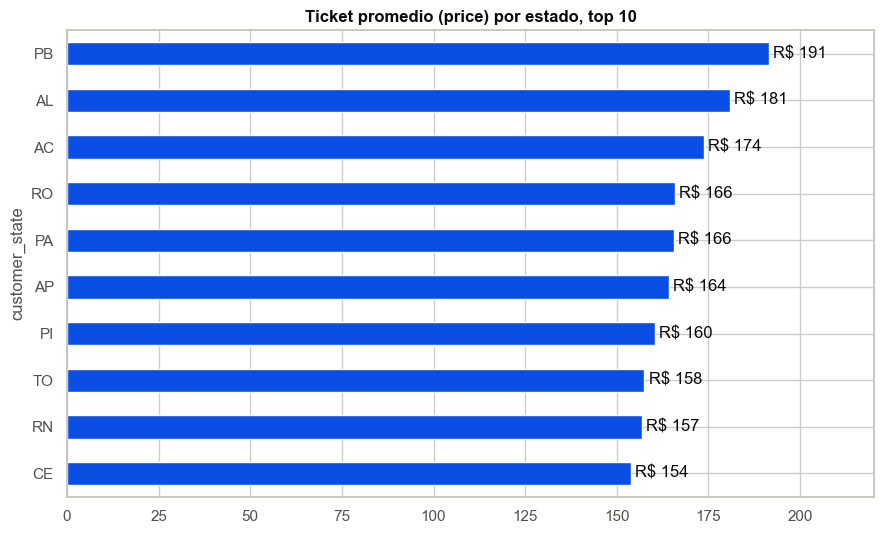

Ticket promedio por región:
region_sudeste
Resto del país    133.5
Sudeste           114.8
Name: price, dtype: float64


In [5]:
ticket_estado = df.groupby("customer_state")["price"].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5.5))
barras = ticket_estado.sort_values().plot(kind="barh", color=OLIST_BLUE, ax=ax)
ax.set_xlim(0, ticket_estado.max() * 1.15)
ax.bar_label(barras.containers[0], fmt="R$ %.0f", padding=3)
ax.set_title("Ticket promedio (price) por estado, top 10")
plt.tight_layout()
guardar_fig()
plt.show()

ticket_region = df.groupby("region_sudeste")["price"].mean().round(2)
print("Ticket promedio por región:")
print(ticket_region)

**Insight:** el ticket promedio **no está concentrado en el Sudeste** — hay estados fuera de esa región con ticket promedio más alto. Es decir: la **brecha logística** (que fuera del Sudeste se espera más y se paga más flete — notebook 10) **no viene acompañada de una brecha de gasto**: los clientes de otras regiones compran productos de valor similar o mayor.

## 5 — Mapa de correlaciones de las variables numéricas clave

**Qué hacemos:** heatmap con la matriz de correlación de Pearson (de -1 a +1) entre 10 variables: precio, flete, `flete_ratio`, tiempo de entrega, distancia, puntaje, volumen, peso e ítems por pedido.

**Para qué:** una **vista compacta de qué variables se mueven juntas** antes de leer hipótesis por hipótesis — sirve como mapa de ruta y para detectar relaciones no obvias.

> **Cómo leer el heatmap:** cercano a **+1** = suben juntas; cercano a **-1** = una sube y la otra baja; cercano a **0** = no tienen relación **lineal** (¡no implica que no tengan relación de otro tipo!).

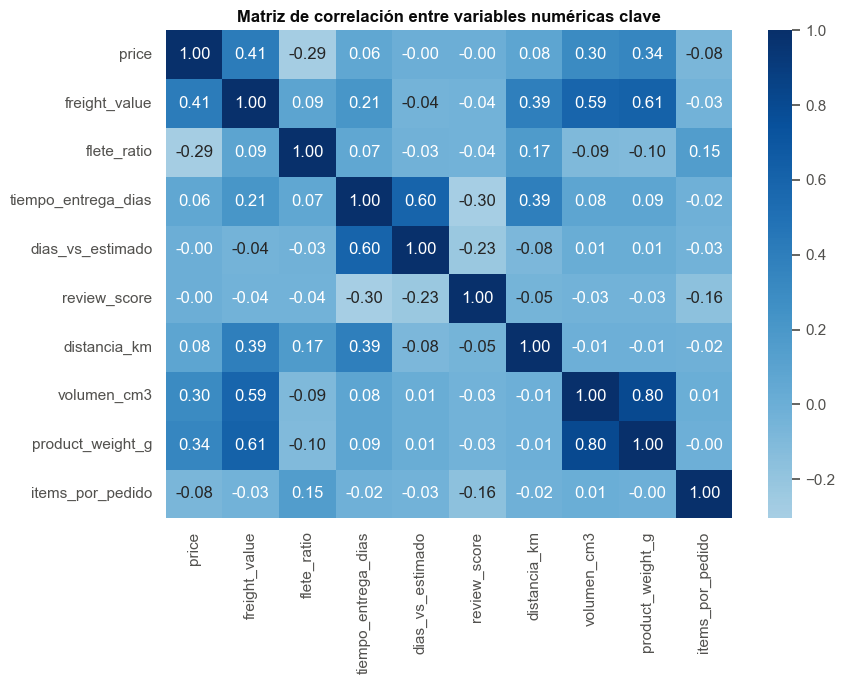

In [6]:
numericas = [
    "price", "freight_value", "flete_ratio", "tiempo_entrega_dias", "dias_vs_estimado",
    "review_score", "distancia_km", "volumen_cm3", "product_weight_g", "items_por_pedido",
]
corr = df[numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", center=0, ax=ax)
ax.set_title("Matriz de correlación entre variables numéricas clave")
plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** la correlación **más fuerte del bloque logístico es `distancia_km` ↔ `tiempo_entrega_dias`**, seguida de `freight_value` ↔ volumen/peso. `review_score` tiene correlaciones **bajas con casi todas las numéricas de forma lineal** — confirma que su relación con la demora es más una **diferencia de grupos** (a tiempo vs. demorado, que sí es clara en el boxplot del notebook 06) que una relación lineal continua: por eso el test de la hipótesis 1 compara **grupos** y no correlaciona.

## 6 — Vendedores: volumen y performance

**Qué hacemos:** dos rankings de vendedores con **al menos 20 pedidos** (`UMBRAL_MIN_PEDIDOS_VENDEDOR`): los 10 de **mayor volumen** de pedidos, y los 10 con **peor % de envíos demorados**.

**Para qué:** un primer acercamiento simple (sin clustering, que queda para la etapa de modelado del script 2) a **qué vendedores concentran el negocio y cuáles tienen peor desempeño logístico** — información directamente accionable para priorizar a quién contactar primero.

In [7]:
UMBRAL_MIN_PEDIDOS_VENDEDOR = 20

ranking_vendedores = df.groupby("seller_id").agg(
    pedidos=("order_id", "nunique"),
    tiempo_entrega_promedio=("tiempo_entrega_dias", "mean"),
    pct_demorado=("envio_demorado", "mean"),
)
ranking_vendedores_filtrado = ranking_vendedores.query("pedidos >= @UMBRAL_MIN_PEDIDOS_VENDEDOR")
if ranking_vendedores_filtrado.empty:
    ranking_vendedores_filtrado = ranking_vendedores  # dataset chico: no filtramos por volumen

ranking_vendedores = ranking_vendedores_filtrado.copy()
ranking_vendedores["pct_demorado"] = (ranking_vendedores["pct_demorado"] * 100).round(1)
ranking_vendedores["tiempo_entrega_promedio"] = ranking_vendedores["tiempo_entrega_promedio"].round(1)

print("Top 10 vendedores por volumen de pedidos:")
print(ranking_vendedores.sort_values("pedidos", ascending=False).head(10))
print()
print("Top 10 vendedores con peor % de envíos demorados (≥20 pedidos):")
print(ranking_vendedores.sort_values("pct_demorado", ascending=False).head(10))

Top 10 vendedores por volumen de pedidos:
                                  pedidos  tiempo_entrega_promedio  \
seller_id                                                            
6560211a19b47992c3666cc44a7e94c0     1854                      9.1   
4a3ca9315b744ce9f8e9374361493884     1806                     13.9   
cc419e0650a3c5ba77189a1882b7556a     1706                     11.1   
1f50f920176fa81dab994f9023523100     1404                     15.1   
da8622b14eb17ae2831f4ac5b9dab84a     1314                     10.7   
955fee9216a65b617aa5c0531780ce60     1287                     10.3   
7a67c85e85bb2ce8582c35f2203ad736     1160                     10.7   
ea8482cd71df3c1969d7b9473ff13abc     1146                     12.9   
4869f7a5dfa277a7dca6462dcf3b52b2     1132                     14.5   
3d871de0142ce09b7081e2b9d1733cb1     1080                     13.0   

                                  pct_demorado  
seller_id                                       
6560211a19b47992c36

**Insight:** los vendedores con **mayor volumen no son los mismos que los de peor % de demora** — el problema logístico **no está concentrado únicamente en los vendedores más grandes**, lo que sugiere que una intervención pareja (capacitación, SLA, cambio de transportista) le serviría a un conjunto de vendedores más amplio que solo los "top".

## 7 — Ticket según cantidad de cuotas

**Qué hacemos:** ticket promedio (`price`) agrupado por la cantidad de cuotas máxima elegida en el pago.

**Para qué:** verificar con los datos si **las compras de mayor valor se financian en más cuotas** — algo esperable, pero conviene confirmarlo antes de asumirlo.

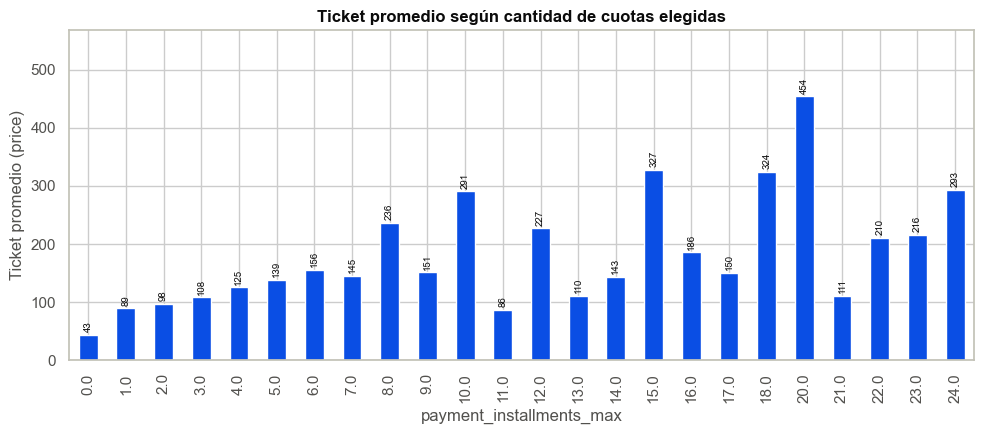

In [8]:
cuotas_ticket = df.groupby("payment_installments_max")["price"].mean().dropna()

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = cuotas_ticket.plot(kind="bar", color=OLIST_BLUE, ax=ax)
ax.bar_label(barras.containers[0], fmt="%.0f", padding=2, fontsize=7, rotation=90)
ax.set_ylim(0, cuotas_ticket.max() * 1.25)
ax.set_ylabel("Ticket promedio (price)")
ax.set_title("Ticket promedio según cantidad de cuotas elegidas")
plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** el ticket promedio **sube de forma consistente** a medida que aumentan las cuotas — el financiamiento en cuotas se usa mayormente para compras de mayor valor, no de forma pareja en todos los rangos de precio.

## 8 — Pareto de facturación por categoría

**Qué hacemos:** sumamos la facturación (`price`) por categoría, calculamos el **% acumulado** y graficamos un Pareto de las 15 categorías top: barras = facturación de cada una, línea = % acumulado del total.

**Para qué:** ver **qué tan concentrada está la facturación** en pocas categorías (lógica 80/20) — para decidir dónde enfocar esfuerzos comerciales o de negociación con vendedores.

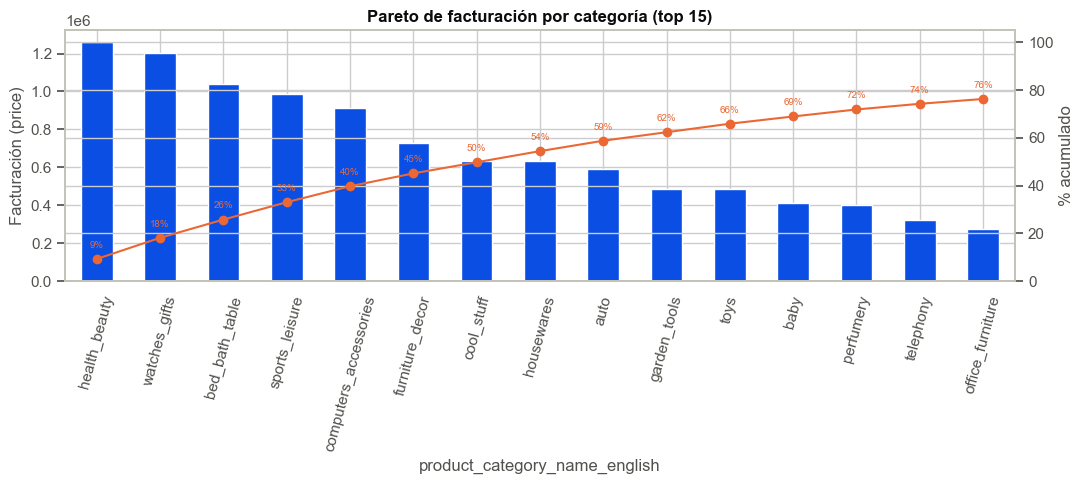

Las 5 categorías top representan el 39.7% de la facturación total.


In [9]:
facturacion_categoria = df.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False)
pct_acumulado = facturacion_categoria.cumsum() / facturacion_categoria.sum() * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
facturacion_categoria.head(15).plot(kind="bar", color=OLIST_BLUE, ax=ax1)
ax1.set_ylabel("Facturación (price)")
ax1.tick_params(axis="x", rotation=75)

ax2 = ax1.twinx()
pct_acumulado.head(15).plot(color=PALETA_CATEGORICA[1], marker="o", ax=ax2)
ax2.set_ylabel("% acumulado")
ax2.set_ylim(0, 105)
for x, y in zip(range(15), pct_acumulado.head(15).values):
    ax2.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=7, color=PALETA_CATEGORICA[1])

ax1.set_title("Pareto de facturación por categoría (top 15)")
plt.tight_layout()
guardar_fig()
plt.show()

print(f"Las 5 categorías top representan el {pct_acumulado.iloc[4]:.1f}% de la facturación total.")

**Insight:** la facturación está **bastante repartida** entre varias categorías — no hay una concentración extrema tipo "2-3 categorías son todo el negocio" —, consistente con un **marketplace generalista** y no con una tienda especializada en pocos rubros.

### Cierre de la sección

Ya sabemos *qué* pasa (demoras, concentración, distancias, vendedores) — ahora falta verlo **en el mapa** (notebook 08), **leer lo que dicen los clientes** (notebook 09) y **contrastar las hipótesis con tests estadísticos** (notebook 10).

**Siguiente paso:** `08_mapa_geografico.ipynb`.